In [11]:
import matplotlib.pyplot as plt
import json
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister, assemble
from qiskit_ibm_runtime import QiskitRuntimeService
from qtcodes import XXZZQubit
import time
import numpy as np
import os
import pandas as pd
import networkx as nx
import networkx as nx
from networkx.algorithms import isomorphism
import random

In [3]:
global api_token, service, backends
api_token = 'be5e713d2a8fa9228e96fbb61a84af3337e4730a2d7a174eaeeb8c625f964b516a29f367490a0fa50ec5de4dff1be879e018c6f87e906a15b379519049c9868a'

service = QiskitRuntimeService(
    channel="ibm_quantum",
    token=api_token,
    #instance="ibm-q-education/columbia-uni-2/computer-science"
)

backends =  service.backends()[:-1]

In [4]:
def circuit_to_connectivity_graph(qc: QuantumCircuit, exclude_ancillas=True) -> nx.Graph:
    """
    Given a Qiskit QuantumCircuit, return a NetworkX Graph
    where nodes represent qubits and edges represent 2-qubit interactions.
    """
    G = nx.Graph()
    
    # Extract qubit mappings
    qubit_mapping = qc.layout.initial_layout.get_physical_bits()  # Maps logical qubits to physical indices
    
    # Identify ancilla qubits
    ancilla_qubits = set()
    if exclude_ancillas:
        for idx, qubit in qubit_mapping.items():
            if "ancilla" == qubit._register.name:  # Filter based on register name
                ancilla_qubits.add(idx)

    # Add edges for each 2-qubit gate (excluding ancillas if requested)
    for instr, qargs, _ in qc.data:
        if len(qargs) == 2:  # Only consider 2-qubit interactions
            q0 = qc.find_bit(qargs[0]).index
            q1 = qc.find_bit(qargs[1]).index

            if exclude_ancillas and (q0 in ancilla_qubits or q1 in ancilla_qubits):
                continue  # Skip ancilla interactions

            G.add_edge(q0, q1)

    return G

def backend_to_graph(backend) -> nx.Graph:
    """
    Given a Qiskit backend (real or simulator),
    build a NetworkX Graph of its qubit connectivity.
    """
    config = backend.configuration()
    coupling_map = config.coupling_map  # e.g. [[0,1],[1,2],...]
    # print(coupling_map)
    
    G = nx.Graph()
    G.add_nodes_from(range(config.num_qubits))
    
    for edge in coupling_map:
        G.add_edge(edge[0], edge[1])  # Undirected edge
    
    return G

def find_random_subgraph_isomorphism(sub_graph, full_graph, max_solutions=50000, verbose=True):
    """
    Returns a random subgraph isomorphism by:
    1. Shuffling node order before searching to introduce randomness.
    2. Collecting up to `max_solutions` valid mappings.
    3. Picking one at random from the collected solutions.

    Parameters:
    - sub_graph: nx.Graph, the smaller graph to embed
    - full_graph: nx.Graph, the larger host graph
    - max_solutions: Maximum number of solutions to collect before choosing randomly
    - verbose: If True, prints status messages

    Returns:
    - A dictionary {sub_node: full_node} representing a random subgraph isomorphism,
      or None if no isomorphism exists.
    """

    # Step 1: Shuffle node order before searching (introduces randomness)
    sub_nodes = list(sub_graph.nodes())
    full_nodes = list(full_graph.nodes())
    
    random.shuffle(sub_nodes)
    random.shuffle(full_nodes)

    # Create a GraphMatcher with shuffled node order
    GM = isomorphism.GraphMatcher(full_graph, sub_graph)

    # Step 2: Collect up to `max_solutions` valid subgraph isomorphisms
    solutions = []
    for mapping in GM.subgraph_isomorphisms_iter():
        # Convert full->sub mapping to sub->full
        sub_to_full = {sub: full for full, sub in mapping.items()}
        solutions.append(sub_to_full)
        if len(solutions) >= max_solutions:
            print(f'Hit max solutions limit: {len(solutions)}')
            break  # Stop early once we reach the desired number of solutions

    if not solutions:
        if verbose:
            print("[FAIL] No subgraph isomorphism found.")
        return None

    # Step 3: Pick one random solution from the collected ones
    chosen_mapping = random.choice(solutions)

    if verbose:
        print(f"[SUCCESS] Found {len(solutions)} subgraph isomorphisms. Picking one at random:")
        for s_node, f_node in chosen_mapping.items():
            print(f"  {s_node} -> {f_node}")

    return chosen_mapping

Backend = ibm_brisbane
	Connectivity graph: 144 edges, 127 nodes
Circuit connectivity graph: 16 edges, 17 nodes


/var/folders/k3/27w60qks2nn1dv0q05k_30z40000gn/T/ipykernel_42711/4079034842.py:19: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for instr, qargs, _ in qc.data:


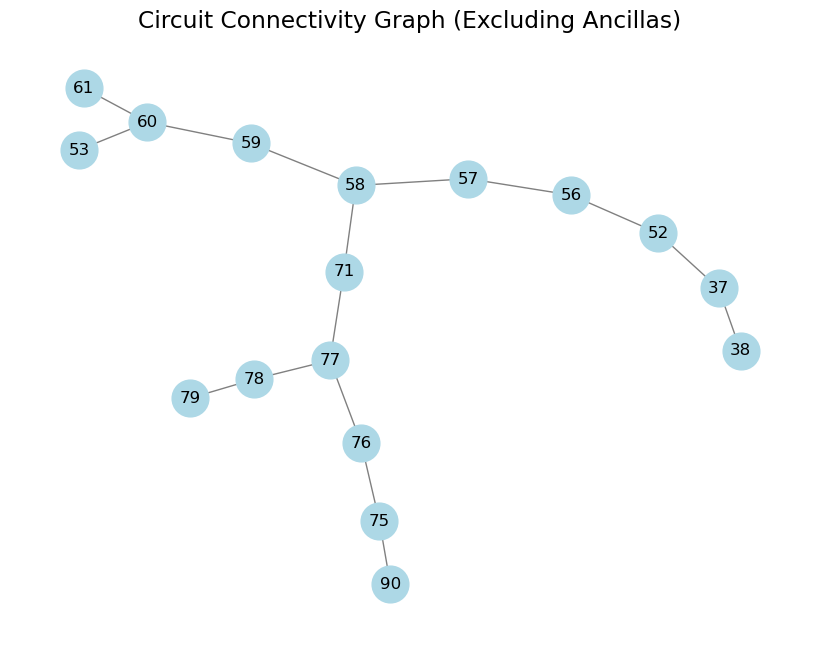

In [8]:
# Pick a backend and build its connectivity graph
backend = backends[0]
print(f'Backend = {backend.name}')
backend_graph = backend_to_graph(backend)
print(f'\tConnectivity graph: {backend_graph.number_of_edges()} edges, {backend_graph.number_of_nodes()} nodes')

qubit_d5_circ = XXZZQubit({'d': 3})
qubit_d5_circ.x()
qubit_d5_circ.stabilize()
qc = transpile(qubit_d5_circ.circ, backend, optimization_level=3) 

#Extract the circuit's connectivity
circ_graph = circuit_to_connectivity_graph(qc)
print(f'Circuit connectivity graph: {circ_graph.number_of_edges()} edges, {circ_graph.number_of_nodes()} nodes')

plt.figure(figsize=(8, 6))
nx.draw(circ_graph, with_labels=True, node_color='lightblue', edge_color='gray', node_size=700)
plt.title("Circuit Connectivity Graph (Excluding Ancillas)")
plt.show()

In [15]:
# Example usage:
sub_mapping = find_random_subgraph_isomorphism(circ_graph, backend_graph)

[SUCCESS] Found 3408 subgraph isomorphisms. Picking one at random:
  59 -> 110
  60 -> 118
  53 -> 117
  58 -> 100
  71 -> 99
  77 -> 98
  76 -> 97
  75 -> 96
  57 -> 101
  56 -> 102
  52 -> 103
  37 -> 104
  78 -> 91
  61 -> 119
  90 -> 95
  38 -> 105
  79 -> 79


In [17]:
def verify_subgraph_isomorphism(sub_graph, full_graph, mapping):
    """
    Checks if 'mapping' is a valid subgraph isomorphism of 'sub_graph' into 'full_graph'.

    mapping: dict {sub_node: full_node}
    """
    # 1) Make sure each sub_graph node maps to a unique full_graph node
    mapped_full_nodes = set(mapping.values())
    if len(mapped_full_nodes) < len(mapping):
        # Means at least two sub_nodes map to the same full_node
        return False
    
    # 2) For every edge in the sub_graph, check if the corresponding edge exists in the full_graph
    for (u, v) in sub_graph.edges():
        if not full_graph.has_edge(mapping[u], mapping[v]):
            return False
    
    # If all checks pass, it's a valid subgraph isomorphism
    return True


In [19]:
# Suppose 'sub_mapping' is what your algorithm / GraphMatcher found
is_iso = verify_subgraph_isomorphism(circ_graph, backend_graph, sub_mapping)
if is_iso:
    print("Verified: The mapping truly forms a subgraph isomorphism.")
else:
    print("Not a valid subgraph isomorphism!")


Verified: The mapping truly forms a subgraph isomorphism.
